In [2]:
# Step 1: Import required libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point


In [3]:
# Step 2: Load raw CSV data
blocks = pd.read_csv("../data/raw/meghalaya/blocks.csv")
districts = pd.read_csv("../data/raw/meghalaya/districts.csv")
schools = pd.read_csv("../data/raw/meghalaya/schools.csv")

print("Blocks:", blocks.shape)
print("Districts:", districts.shape)
print("Schools:", schools.shape)


Blocks: (48, 8)
Districts: (12, 8)
Schools: (12031, 43)


In [4]:
# Step 3: Clean blocks data
blocks_clean = blocks[[
    "_id",
    "blockName",
    "districtID",
    "govtBlockId"
]]

blocks_clean.columns = [
    "block_id",
    "block_name",
    "district_id",
    "govt_block_id"
]

blocks_clean.head()


,block_id,block_name,district_id,govt_block_id
0,660f8d79ecf58e7e735f49ec,MAWLAI,65e6b420805e43c45e04c5a4,170612
1,65e6bc9650589fd545144695,KHATAR SHNONG - LAITKROH,65e6b420805e43c45e04c5a4,170608
2,66a35e17847ef156cad45722,TIKRIKILLA,660d0192d83fdbd7e0e8126d,170103
3,66a35e39847ef156cad4577e,DEMDEMA,660d0192d83fdbd7e0e8126d,170108
4,66a35d91847ef156cad455df,LASKEIN,66a35ba2847ef156cad45591,170702


In [5]:
# Step 4: Clean districts data
districts_clean = districts[[
    "_id",
    "districtName",
    "govtDistrictId"
]]

districts_clean.columns = [
    "district_id",
    "district_name",
    "govt_district_id"
]

districts_clean.head()


,district_id,district_name,govt_district_id
0,67c6ada157f5829f07d44cfc,SOUTH WEST GARO HILLS,1711
1,65e6b420805e43c45e04c5a4,EAST KHASI HILLS,1706
2,67c6b7fee202caba8817916b,EASTERN WEST KHASI HILLS,1712
3,67c6b7ffe202caba88179189,WEST KHASI HILLS,1704
4,66a36d363fae128449d03aaa,RI BHOI,1705


In [6]:
# Step 5: Clean schools data
schools_clean = schools[[
    "schoolName",
    "districtID",
    "blockID",
    "schoolType",
    "schoolCategory",
    "schoolLatitude",
    "schoolLongitude"
]]

schools_clean.columns = [
    "school_name",
    "district_id",
    "block_id",
    "school_type",
    "school_category",
    "lat",
    "lon"
]

schools_clean = schools_clean.dropna(subset=["lat", "lon"])
schools_clean["lat"] = schools_clean["lat"].astype(float)
schools_clean["lon"] = schools_clean["lon"].astype(float)

schools_clean.head()


,school_name,district_id,block_id,school_type,school_category,lat,lon
0,MAWLAITENG GOVT. UP SCHOOL,65e6b420805e43c45e04c5a4,65e6b4e70346b321cc356a68,Co-ed,4 - Upper Primary only,25.482990,91.657490
1,NONGRIM SADEW GOVT. LP,65e6b420805e43c45e04c5a4,65e6b63850589fd545144658,Co-ed,1 - Primary,25.455570,91.735710
2,PENIEL ENGLISH SSA UP SCHOOL- LAITKROH,65e6b420805e43c45e04c5a4,65e6bc9650589fd545144695,Co-ed,4 - Upper Primary only,25.439574,91.799192
3,SPRINGSIDE SSA UP SCHOOL,65e6b420805e43c45e04c5a4,65e6bb3750589fd54514467f,Co-ed,4 - Upper Primary only,25.305412,91.725699
4,GOVT. UPS MOWKAIAW,66a35ba2847ef156cad45591,66a35d91847ef156cad455df,Co-ed,7 - Upper Pr. and Secondary,25.524691,92.434709


In [7]:
# Step 6: Convert schools to GeoDataFrame
schools_gdf = gpd.GeoDataFrame(
    schools_clean,
    geometry=gpd.points_from_xy(schools_clean.lon, schools_clean.lat),
    crs="EPSG:4326"
)

schools_gdf.head()


,school_name,district_id,block_id,school_type,school_category,lat,lon,geometry
0,MAWLAITENG GOVT. UP SCHOOL,65e6b420805e43c45e04c5a4,65e6b4e70346b321cc356a68,Co-ed,4 - Upper Primary only,25.482990,91.657490,POINT (91.65749 25.48299)
1,NONGRIM SADEW GOVT. LP,65e6b420805e43c45e04c5a4,65e6b63850589fd545144658,Co-ed,1 - Primary,25.455570,91.735710,POINT (91.73571 25.45557)
2,PENIEL ENGLISH SSA UP SCHOOL- LAITKROH,65e6b420805e43c45e04c5a4,65e6bc9650589fd545144695,Co-ed,4 - Upper Primary only,25.439574,91.799192,POINT (91.79919 25.43957)
3,SPRINGSIDE SSA UP SCHOOL,65e6b420805e43c45e04c5a4,65e6bb3750589fd54514467f,Co-ed,4 - Upper Primary only,25.305412,91.725699,POINT (91.7257 25.30541)
4,GOVT. UPS MOWKAIAW,66a35ba2847ef156cad45591,66a35d91847ef156cad455df,Co-ed,7 - Upper Pr. and Secondary,25.524691,92.434709,POINT (92.43471 25.52469)


In [8]:
# Step 7: Load block shapefile
blocks_shape = gpd.read_file("../data/raw/meghalaya/boundaries/block/block.shp")

# Normalize column names
blocks_shape = blocks_shape.rename(columns={
    "block": "block_name",
    "district": "district_name"
})

blocks_shape["block_name"] = blocks_shape["block_name"].str.upper().str.strip()

blocks_shape.head()


,district_name,block_name,length,area_sqkm,area_ha,geometry
0,Ri Bhoi,JIRANG,245992.302974,663.784610,66378.460998,"POLYGON ((91.79591 25.83289, 91.79484 25.83246..."
1,Ri Bhoi,UMSNING,243348.566830,672.672467,67267.246705,"POLYGON ((92.16248 25.82693, 92.16243 25.82695..."
2,Ri Bhoi,UMLING,174192.987300,705.096018,70509.601839,"POLYGON ((92.13274 26.04485, 92.13316 26.04456..."
3,East Jaintia Hills,SAIPUNG,206436.144271,1071.902761,107190.276136,"POLYGON ((92.52237 25.13952, 92.52237 25.13959..."
4,East Jaintia Hills,KHLIEHRIAT,218166.350734,971.285079,97128.507887,"POLYGON ((92.405 25.44682, 92.40488 25.4466, 9..."


In [9]:
# Step 8: Merge block attributes with spatial data
blocks_merged = blocks_shape.merge(
    blocks_clean,
    on="block_name",
    how="left"
)


In [10]:
# Step 9: Count schools per block
block_school_counts = (
    schools_clean
    .groupby("block_id")
    .size()
    .reset_index(name="total_schools")
)

block_school_counts.head()


,block_id,total_schools
0,65e6b4e70346b321cc356a68,212
1,65e6b5ef50589fd545144652,127
2,65e6b63850589fd545144658,211
3,65e6b7c250589fd54514465e,206
4,65e6ba7050589fd545144673,239


In [11]:
blocks_final = blocks_merged.merge(
    block_school_counts,
    on="block_id",
    how="left"
)

blocks_final["total_schools"] = blocks_final["total_schools"].fillna(0)


In [12]:
blocks_gdf = gpd.GeoDataFrame(
    blocks_final,
    geometry="geometry",
    crs="EPSG:4326"
)


<Axes: >

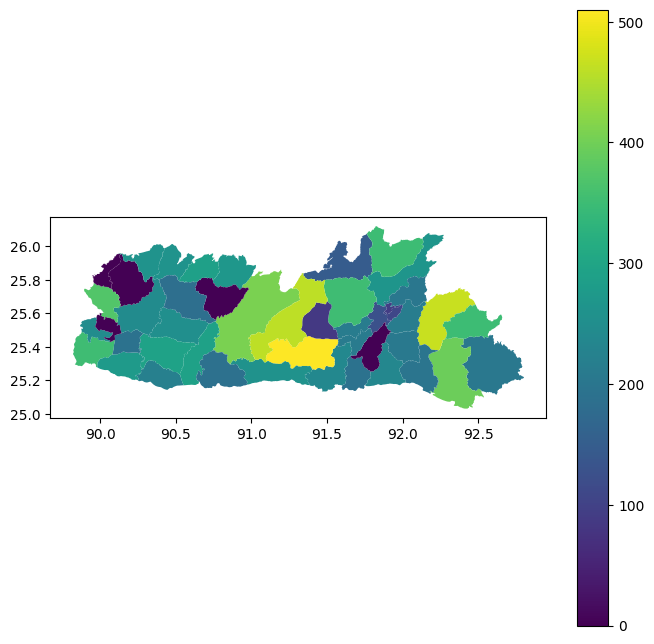

In [13]:
blocks_gdf.plot(column="total_schools", figsize=(8, 8), legend=True)


In [16]:
blocks_gdf.to_file(
    "data/processed/meghalaya/blocks_final.geojson",
    driver="GeoJSON"
)


In [15]:
import os

os.makedirs("data/processed/meghalaya", exist_ok=True)
